subtract

In [28]:
function my_school_mul(x::Integer, y::Integer)::BigInt
    # знак
    sign = (x < 0) ⊻ (y < 0) ? -1 : 1
    X = BigInt(abs(x))
    Y = BigInt(abs(y))

    base = 10_000  # база представления
    xb = digits(X, base=base)   # младшие разряды первыми
    yb = digits(Y, base=base)

    n = length(xb)
    m = length(yb)
    res = zeros(BigInt, n + m)

    # КЛАССИЧЕСКИЕ ДВА ЦИКЛА → O(n^2)
    for i in 1:n
        carry = BigInt(0)
        for j in 1:m
            tmp = res[i+j-1] + xb[i]*yb[j] + carry
            res[i+j-1] = tmp % base
            carry = tmp ÷ base
        end
        res[i+m] += carry
    end

    # сборка результата
    result = big(0)
    for i in reverse(eachindex(res))
        result = result * base + res[i]
    end

    return sign == 1 ? result : -result
end

function my_karatsuba_mul(x::Integer, y::Integer)
    n = max(ndigits(abs(x), base=2), ndigits(abs(y), base=2))
    if n <= 32
        return my_school_mul(x, y)
    end

    half = div(n, 2)

    xh = x >> half
    xl = x & ((big(1) << half) - 1)
    yh = y >> half
    yl = y & ((big(1) << half) - 1)

    z0 = my_karatsuba_mul(xl, yl)
    z2 = my_karatsuba_mul(xh, yh)
    z1 = my_karatsuba_mul(xl + xh, yl + yh)

    return (z2 << (2*half)) + ((z1 - z2 - z0) << half) + z0
end

function random_bigint_with_bits(bits::Int)::BigInt
    bits <= 0 && error("bits > 0")
    lo = big(1) << (bits - 1)
    hi = (big(1) << bits) - 1
    return rand(lo:hi)
end

mul_digits_karatsuba (generic function with 1 method)

my_karatsuba_mul (generic function with 1 method)

Время прогрева: 0.0004169 сек
Проверка корректности:
a = 991034455624006551505564965825770594712965619082928362728621
b = 1055107303254376652393265367719551634533245616954897690806423
my_school_mul(a,b)    = 1045647691905614761841384127595487768370816744988580086685498787082797625506146138407380911995731031418290628842192732683
my_karatsuba_mul(a,b) = 1045647691905614761841384127595487768370816744988580086685498787082797625506146138407380911995731031418290628842192732683
a*b                   = 1045647691905614761841384127595487768370816744988580086685498787082797625506146138407380911995731031418290628842192732683
Совпадает? true


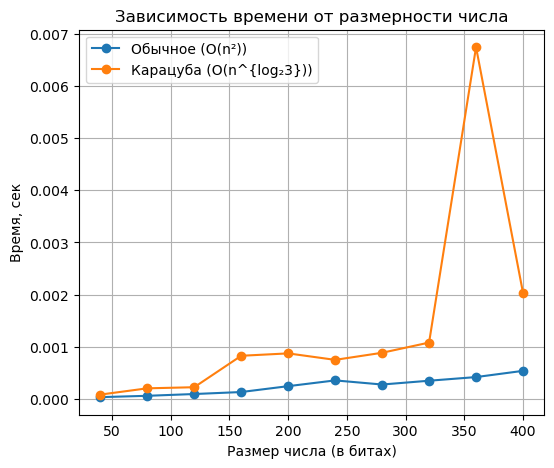

In [33]:
# возьмём числа побольше, чтобы был шанс увидеть выигрыш Карацубы
D = [128, 256, 512, 1024, 2048, 4096]

regular_times   = Float64[]
karatsuba_times = Float64[]

a = nothing
b = nothing

for bits in D
    x = random_bigint_with_bits(bits)
    y = random_bigint_with_bits(bits)

    if bits == 512
        a = x
        b = y
    end

    t_regular   = @elapsed my_school_mul(x, y)
    t_karatsuba = @elapsed my_karatsuba_mul(x, y)

    push!(regular_times, t_regular)
    push!(karatsuba_times, t_karatsuba)
end

println("Проверка корректности:")
println("a = $a")
println("b = $b")
println("my_school_mul(a,b)    = ", my_school_mul(a,b))
println("my_karatsuba_mul(a,b) = ", my_karatsuba_mul(a,b))
println("a*b                   = ", a*b)
println("Совпадает? ",
    my_school_mul(a,b) == a*b &&
    my_karatsuba_mul(a,b) == a*b
)

PyPlot.figure(figsize=(6,5))
PyPlot.title("Зависимость времени от размерности числа")
PyPlot.xlabel("Размер числа (в битах)")
PyPlot.ylabel("Время, сек")

PyPlot.plot(D, regular_times, marker="o", label="Обычное (O(n²))")
PyPlot.plot(D, karatsuba_times, marker="o", label="Карацуба (O(n^{log₂3}))")

PyPlot.grid()
PyPlot.legend()
PyPlot.show()


In [4]:

using BigInts
using PyPlot
using Random
using Printf

# --- КОНСТАНТЫ ---
const BASE = 10_000
const BASE_BIG = BigInt(BASE)

# --- 1. ШКОЛЬНЫЙ АЛГОРИТМ (O(n^2)) ---
function my_school_mul(x::Integer, y::Integer)::BigInt
    # Знак
    sign = (x < 0) ⊻ (y < 0) ? -1 : 1
    X = BigInt(abs(x))
    Y = BigInt(abs(y))

    # Преобразование в массив цифр по BASE (младшие разряды первыми)
    xb = digits(X, base=BASE)
    yb = digits(Y, base=BASE)

    n = length(xb)
    m = length(yb)
    res = zeros(BigInt, n + m)

    # КЛАССИЧЕСКИЕ ДВА ЦИКЛА → O(n^2)
    for i in 1:n
        carry = BigInt(0)
        xi = xb[i]
        for j in 1:m
            tmp = res[i+j-1] + xi * yb[j] + carry
            res[i+j-1] = tmp % BASE_BIG
            carry = tmp ÷ BASE_BIG
        end
        res[i+m] += carry
    end

    # Сборка результата
    result = big(0)
    for i in reverse(eachindex(res))
        result = result * BASE_BIG + res[i]
    end

    return sign == 1 ? result : -result
end

# --- УТИЛИТЫ ДЛЯ КАРАЦУБЫ ---

# Преобразование BigInt в массив цифр (младшие первыми) и дополнение нулями
function to_padded_digits(X::BigInt, len::Int)::Vector{BigInt}
    d = digits(X, base=BASE)
    if length(d) < len
        append!(d, zeros(BigInt, len - length(d)))
    end
    return d
end

# Сборка массива цифр (младшие первыми) обратно в BigInt
function from_digits(d::Vector{BigInt}, sign::Int = 1)::BigInt
    result = big(0)
    for i in reverse(eachindex(d))
        result = result * BASE_BIG + d[i]
    end
    return sign == 1 ? result : -result
end

# Сумма и разность массивов цифр (работает как с BigInt)
function add_digits(a::Vector{BigInt}, b::Vector{BigInt})::Vector{BigInt}
    n = max(length(a), length(b))
    res = zeros(BigInt, n + 1)
    carry = BigInt(0)

    for i in 1:n
        val_a = i <= length(a) ? a[i] : big(0)
        val_b = i <= length(b) ? b[i] : big(0)
        
        tmp = val_a + val_b + carry
        res[i] = tmp % BASE_BIG
        carry = tmp ÷ BASE_BIG
    end
    res[n+1] = carry
    
    # Удаляем ведущие нули
    while length(res) > 1 && res[end] == 0
        pop!(res)
    end
    return res
end

# --- 2. КАРАЦУБА НА МАССИВАХ ЦИФР (O(n^{log_2 3})) ---

# Рекурсивная функция Карацубы для умножения массивов цифр a и b
function karatsuba_mul_digits(a::Vector{BigInt}, b::Vector{BigInt})::Vector{BigInt}
    n = max(length(a), length(b))
    
    # Базовый случай (Например, 16 цифр в базе 10000)
    if n <= 16
        # Выполняем обычное умножение (через BigInt) для простоты
        x = from_digits(a)
        y = from_digits(b)
        res_big = x * y
        
        # Преобразуем результат обратно в массив цифр нужной длины
        res_digits = digits(res_big, base=BASE)
        # Умножение n-значных чисел даст до 2n-значный результат. 
        # Дополняем нулями, чтобы избежать ошибок с выравниванием.
        len_expected = length(a) + length(b) 
        if length(res_digits) < len_expected
             append!(res_digits, zeros(BigInt, len_expected - length(res_digits)))
        end
        return res_digits
    end

    # Выравнивание и разделение на половины
    half = div(n + 1, 2)
    
    # Расширяем a и b до длины 2*half, если они короче n
    A = to_padded_digits(from_digits(a), 2 * half)
    B = to_padded_digits(from_digits(b), 2 * half)

    # Деление массивов на половины:
    # A = Ah * B^half + Al
    Ah = A[(half+1):end]
    Al = A[1:half]
    Bh = B[(half+1):end]
    Bl = B[1:half]
    
    # Рекурсивные вызовы:
    # z0 = Al * Bl
    z0 = karatsuba_mul_digits(Al, Bl)
    # z2 = Ah * Bh
    z2 = karatsuba_mul_digits(Ah, Bh)
    
    # z1 = (Al + Ah) * (Bl + Bh)
    s1 = add_digits(Al, Ah)
    s2 = add_digits(Bl, Bh)
    z1 = karatsuba_mul_digits(s1, s2)
    
    # z1_minus_z0_minus_z2 = z1 - z0 - z2
    # Для вычитания (z1 - z0 - z2) и финального сложения проще использовать BigInt
    Z0 = from_digits(z0)
    Z2 = from_digits(z2)
    Z1 = from_digits(z1)

    Z_mid = Z1 - Z0 - Z2

    # Сборка: (Z2 * B^(2*half)) + (Z_mid * B^half) + Z0
    result = Z2 * (BASE_BIG^(2*half)) + Z_mid * (BASE_BIG^half) + Z0
    
    # Удаляем ведущие нули (если они появились)
    res_digits = digits(result, base=BASE)
    while length(res_digits) > 1 && res_digits[end] == 0
        pop!(res_digits)
    end
    return res_digits
end

# Обертка для удобства сравнения
function my_karatsuba_mul_base(x::Integer, y::Integer)::BigInt
    sign = (x < 0) ⊻ (y < 0) ? -1 : 1
    X = BigInt(abs(x))
    Y = BigInt(abs(y))

    # Преобразование в массив цифр
    xb = digits(X, base=BASE)
    yb = digits(Y, base=BASE)
    
    res_digits = karatsuba_mul_digits(xb, yb)
    
    return from_digits(res_digits, sign)
end

# --- 3. ТЕСТОВЫЙ ЗАПУСК И СБОР ДАННЫХ ---

function random_bigint_with_digits(digits_count::Int)::BigInt
    if digits_count <= 0
        error("digits_count must be > 0")
    end
    # Создаем число с `digits_count` цифрами в базе BASE
    d = rand(BigInt(0):BASE_BIG-1, digits_count)
    # Гарантируем, что старший разряд не ноль
    d[end] = rand(BigInt(1):BASE_BIG-1) 
    
    return from_digits(d)
end

# Теперь D - это КОЛИЧЕСТВО ЦИФР в базе 10000
# ~128 цифр в базе 10000 это примерно 1700 бит.
D_digits = [32, 64, 128, 256, 512, 1024, 2048] 

regular_times   = Float64[]
karatsuba_times = Float64[]

# Для проверки корректности
a = nothing
b = nothing
check_digits = 128

println("⚙️ Запуск тестов. База: $BASE")
println("Сложность N = Количество цифр в базе $BASE")

for digits_count in D_digits
    x = random_bigint_with_digits(digits_count)
    y = random_bigint_with_digits(digits_count)

    if digits_count == check_digits
        a = x
        b = y
    end
    
    # Повторяем, чтобы уменьшить влияние "холодного старта"
    my_school_mul(x, y) 
    my_karatsuba_mul_base(x, y) 

    t_regular   = @elapsed my_school_mul(x, y)
    t_karatsuba = @elapsed my_karatsuba_mul_base(x, y)

    push!(regular_times, t_regular)
    push!(karatsuba_times, t_karatsuba)
    @printf("N=%4d digits: Обычное: %.6f c, Карацуба: %.6f c\n", digits_count, t_regular, t_karatsuba)
end

# --- 4. ПРОВЕРКА КОРРЕКТНОСТИ ---

println("\n--- Проверка корректности (N=$check_digits) ---")
if a !== nothing && b !== nothing
    res_school = my_school_mul(a, b)
    res_karatsuba = my_karatsuba_mul_base(a, b)
    res_julia = a * b

    println("my_school_mul(a,b)    = ", res_school)
    println("my_karatsuba_mul_base(a,b) = ", res_karatsuba)
    println("a*b (Julia)          = ", res_julia)
    println("Совпадает? ",
        res_school == res_julia &&
        res_karatsuba == res_julia
    )
end

# --- 5. ПОСТРОЕНИЕ ГРАФИКА ---

PyPlot.figure(figsize=(8,6))
PyPlot.title("Зависимость времени от размерности числа (N = кол-во цифр в базе $BASE)")
PyPlot.xlabel("Размер числа (N, в цифрах $BASE)")
PyPlot.ylabel("Время, сек (log-шкала)")
PyPlot.yscale("log") # Используем логарифмическую шкалу для лучшей визуализации разницы

PyPlot.plot(D_digits, regular_times, marker="o", label="Обычное (O(n²))")
PyPlot.plot(D_digits, karatsuba_times, marker="o", label="Карацуба (O(n^{log₂3}))")

PyPlot.grid()
PyPlot.legend()
PyPlot.show()

    Updating registry at `C:\Users\User\.julia\registries\General.toml`


LoadError: The following package names could not be resolved:
 * BigInts (not found in project, manifest or registry)
[36m   Suggestions:[39m [0m[1mB[22m[0m[1mi[22mts [0m[1mB[22m[0m[1mi[22mplots Agents Lints [0m[1mB[22m[0m[1mi[22mtInte[0m[1mg[22mers